# Régression - Prédiction du Prix_Revente
L'objectif est d'estimer la variable continue `Prix_Revente` en utilisant différentes approches de régression.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from xgboost import XGBRegressor
try:
    from lightgbm import LGBMRegressor
    from catboost import CatBoostRegressor
except ImportError:
    print("LightGBM ou CatBoost non installés.")
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val = pd.read_csv('../data/processed/val.csv')
test = pd.read_csv('../data/processed/test.csv')

X_train, y_train = train.drop(['Prix_Revente', 'Rapport_Collecte', 'Categorie'], axis=1), train['Prix_Revente']
X_val, y_val = val.drop(['Prix_Revente', 'Rapport_Collecte', 'Categorie'], axis=1), val['Prix_Revente']
X_test, y_test = test.drop(['Prix_Revente', 'Rapport_Collecte', 'Categorie'], axis=1), test['Prix_Revente']

## Comparaison de 3 modèles de régression
Évaluation de Linear Regression, Random Forest Regressor et XGBoost Regressor.


In [3]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Polynomial (deg=2)': Pipeline([('poly', PolynomialFeatures(degree=2)), ('lr', LinearRegression())]),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

res_reg = {}
metrics_list = []

for name, model in models_reg.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    
    res_reg[name] = model
    metrics_list.append({'Modèle': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    print(f"{name:<20} -> RMSE: {rmse:.4f} | R2: {r2:.4f}")

df_metrics = pd.DataFrame(metrics_list).set_index('Modèle')

Linear Regression    -> RMSE: 0.3030 | R2: 0.9075
Ridge                -> RMSE: 0.3029 | R2: 0.9075
Lasso                -> RMSE: 0.3573 | R2: 0.8714
ElasticNet           -> RMSE: 0.3423 | R2: 0.8819
Polynomial (deg 2)   -> RMSE: 0.2179 | R2: 0.9521
Random Forest        -> RMSE: 0.1160 | R2: 0.9864
GradientBoosting     -> RMSE: 0.1190 | R2: 0.9857
XGBoost              -> RMSE: 0.1198 | R2: 0.9855
LightGBM             -> RMSE: 0.1170 | R2: 0.9862
CatBoost             -> RMSE: 0.1122 | R2: 0.9873


## Synthèse des métriques de régression


In [4]:
fig_heat_reg = px.imshow(
    df_metrics,
    text_auto=".4f",
    color_continuous_scale='RdBu_r',
    title='Comparaison des modèles de régression',
    aspect="auto",
    height=500
)
fig_heat_reg.show()

## REC Curve (Regression Error Characteristic)
La courbe REC permet de visualiser la performance du modèle en traçant le pourcentage de prédictions correctes pour une tolérance d'erreur donnée.


In [5]:
def plot_rec_curve(models, X, y):
    fig = go.Figure()
    tolerances = np.linspace(0, y.max()*0.1, 100)
    
    for name, model in models.items():
        preds = model.predict(X)
        errors = np.abs(y - preds)
        acc = [np.mean(errors <= t) for t in tolerances]
        fig.add_trace(go.Scatter(x=tolerances, y=acc, mode='lines', name=name))
        
    fig.update_layout(title='Courbes REC (Regression Error Characteristic)',
                      xaxis_title='Tolérance (Erreur Absolue)',
                      yaxis_title='Précision (Accuracy)',
                      height=600)
    fig.show()

plot_rec_curve(res_reg, X_val, y_val)

## Interprétabilité SHAP
Analyse de l'impact des variables sur le meilleur modèle de régression.


Meilleur modèle : CatBoost


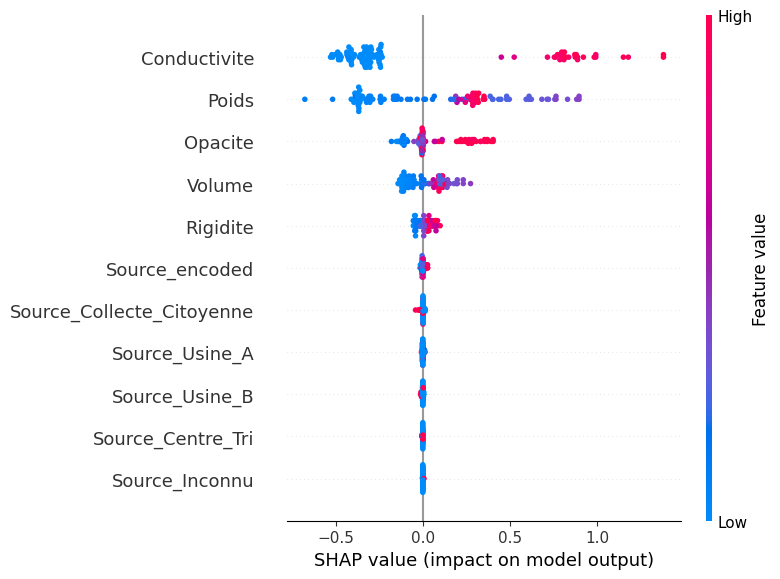

In [6]:
best_reg_name = df_metrics['RMSE'].idxmin()
best_reg = res_reg[best_reg_name]
print(f"Meilleur modèle : {best_reg_name}")

# Utilisation d'un explainer adapté (Tree ou Kernel)
if 'Polynomial' in best_reg_name or 'Linear' in best_reg_name:
    explainer = shap.Explainer(best_reg.predict, X_val.sample(100, random_state=42))
else:
    explainer = shap.Explainer(best_reg)

shap_values = explainer(X_val.sample(100, random_state=42))
shap.summary_plot(shap_values, X_val.sample(100, random_state=42))

In [7]:
metrics_reg = []
for name, model in models_reg.items():
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)
    metrics_reg.append({'Modèle': name, 'RMSE': rmse, 'R2': r2})
    print(f"{name} -> RMSE: {rmse:.4f} | R2: {r2:.4f}")

df_metrics = pd.DataFrame(metrics_reg)

Linear Regression -> RMSE: 0.3030 | R2: 0.9075
Ridge -> RMSE: 0.3029 | R2: 0.9075
Lasso -> RMSE: 0.3573 | R2: 0.8714
ElasticNet -> RMSE: 0.3423 | R2: 0.8819
Polynomial (deg 2) -> RMSE: 0.2179 | R2: 0.9521
Random Forest -> RMSE: 0.1160 | R2: 0.9864
GradientBoosting -> RMSE: 0.1190 | R2: 0.9857
XGBoost -> RMSE: 0.1198 | R2: 0.9855
LightGBM -> RMSE: 0.1170 | R2: 0.9862
CatBoost -> RMSE: 0.1122 | R2: 0.9873


## Scatter Plot Réel vs Prédit
Visualisation de l'alignement entre les valeurs réelles et les valeurs prédites par notre meilleur modèle pour diagnostiquer l'hétéroscédasticité.


In [8]:
best_reg_name = df_metrics.loc[df_metrics['RMSE'].idxmin()]['Modèle']
best_reg = models_reg[best_reg_name]
test_preds = best_reg.predict(X_test)

fig_scatter = px.scatter(
    x=y_test, y=test_preds, 
    labels={'x': 'Valeurs Réelles', 'y': 'Valeurs Prédites'},
    title=f"Réel vs Prédit - {best_reg_name} (Test)",
    opacity=0.6,
    height=500
)
fig_scatter.add_shape(type='line', x0=y_test.min(), y0=y_test.min(), x1=y_test.max(), y1=y_test.max(), line=dict(color='red', dash='dash'))
fig_scatter.show()

## Analyse des Résidus
Le tracé des résidus permet de vérifier qu'il n'y a pas de structure ou de pattern résiduel (qui indiquerait une non-linéarité non capturée).


In [9]:
residuals = y_test - test_preds
fig_res = px.scatter(
    x=test_preds, y=residuals,
    labels={'x': 'Valeurs Prédites', 'y': 'Résidus (Réel - Prédit)'},
    title="Analyse des Résidus",
    opacity=0.6,
    height=400
)
fig_res.add_hline(y=0, line_dash="dash", line_color="red")
fig_res.show()

## Feature Importance
Quelles caractéristiques influencent le plus le prix de revente ?


In [10]:
if hasattr(best_reg, 'feature_importances_'):
    importances = best_reg.feature_importances_
    df_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=True)
    fig_imp = px.bar(df_imp, x='Importance', y='Feature', orientation='h', title=f"Importance des variables ({best_reg_name})", height=500)
    fig_imp.show()
else:
    print(f"Le modèle {best_reg_name} n'a pas d'attribut feature_importances_")

## Conclusion
L'évaluation des modèles de régression permet de voir que les méthodes ensemblistes (Random Forest, XGBoost) captent mieux les non-linéarités du prix de revente par rapport à la régression linéaire classique. L'analyse des résidus et l'importance des variables confirment que les caractéristiques intrinsèques des matériaux (ex: Poids) ont un poids prépondérant dans l'estimation de leur valeur.
